# Simulated go-to tour over the real playfield

A photo of the real playfield, with a **simulated** robot tour drawn on top.
Each iteration ranks the 16 colored targets (8 rectangles + 8 dots) by distance,
drops the closest 4, and picks one at random; the firmware **`G` arc go-to**
(`turnGate=35`) drives there in simulation. **Each path segment is colored by
the target it is heading toward.**

World→pixel uses the camera's calibrated homography (verified against the
detected squares to < 0.5 px).

In [1]:
%matplotlib inline
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
import math, subprocess, pathlib, sys, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CWD = pathlib.Path.cwd()
REPO = CWD.parent if CWD.name == "host_tests" else CWD
HOST = REPO / "host"
if str(HOST) not in sys.path:
    sys.path.insert(0, str(HOST))
print("Building libfirmware_host..."); sys.stdout.flush()
subprocess.run(["cmake", "--build", str(REPO / "host_tests" / "build"), "--", "-j4"],
               cwd=REPO, check=True)
print("Build OK")
from robot_radio.io.sim_conn import SimConnection

# ── camera picture + calibrated world→pixel transform ───────────────────────
IMG = REPO / "host_tests" / "playfield.jpg"
# Homography (raw pixel → corner-origin field cm) from get_playfield_info.
H = np.array([[ 0.13379892005396699, -0.0008557998761684216, -19.642151795230305],
              [ 0.001720935887880159,  0.13690784142077658,    -7.491682188786229],
              [-2.6258459555199083e-05, 2.3558643246032503e-05,  1.0]])
A1_PIXEL = np.array([646.0862, 370.0693, 1.0])     # AprilTag A1 centre (stable)
_a1 = H @ A1_PIXEL; _a1 = _a1 / _a1[2]
A1CX, A1CY = _a1[0], _a1[1]                          # A1 in the corner frame
Hinv = np.linalg.inv(H)

def world_to_pixel(xc, yc):
    """A1-centred world cm (+x east, +y north) → raw image pixel."""
    cx = xc + A1CX            # A1-centred → corner-frame x
    cy = A1CY - yc            # +y north → +y down (image)
    p = Hinv @ np.array([cx, cy, 1.0]); p = p / p[2]
    return p[0], p[1]

print("verify red-W (-35.8,0.55) →",
      tuple(round(v, 1) for v in world_to_pixel(-35.8, 0.55)), "(want ~382.7,371.8)")

# ── targets (A1-centred cm) + colors, from data/aprilcam/playfield.json ─────
SITES = [
    ("purple", -35, 24), ("black", 0, 24), ("orange", 35, 24), ("red", 35, 0),
    ("green", 35, -24), ("magenta", 0, -24), ("blue", -35, -24), ("red", -35, 0),
    ("orange", -50, 30), ("green", 0, 30), ("orange", 50, 30), ("red", 50, 0),
    ("orange", 50, -30), ("yellow", 0, -30), ("orange", -50, -30), ("blue", -50, 0),
]
CMAP = {"purple": "#9b30ff", "black": "#101010", "orange": "#ff8c00",
        "red": "#ff2020", "green": "#18c018", "magenta": "#ff20c0",
        "blue": "#2060ff", "yellow": "#ffd000"}
print(f"{len(SITES)} targets loaded")

Building libfirmware_host...


[  7%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-c/source/robot/DefaultConfig.cpp.o
[  7%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-c/source/robot/Robot.cpp.o


[ 11%] Linking CXX shared library libfirmware_host.dylib


[100%] Built target firmware_host
Build OK
verify red-W (-35.8,0.55) → (np.float64(382.4), np.float64(371.6)) (want ~382.7,371.8)
16 targets loaded


In [2]:
def make_robot():
    c = SimConnection(); c.connect()
    c.set_slip(0.0, 0.0); c.set_encoder_noise(0.0)
    c.send("SET sTimeout=60000")   # sim: keep the safety watchdog out of the way
    c.send("SET turnGate=35")
    c.set_enc(0.0, 0.0); c.tick(50)
    return c


def drive_to(c, tx_cm, ty_cm, speed=200, arrive_mm=60, max_ms=14000, dt=40):
    """Drive to (tx,ty) world-cm with the firmware G; return the TRUE path [cm]."""
    pts = []
    tx, ty = tx_cm * 10.0, ty_cm * 10.0
    for _ in range(3):
        p = c.get_exact_pose(); rx, ry, rh = p["x"], p["y"], p["h"]
        if math.hypot(tx - rx, ty - ry) <= arrive_mm:
            break
        dx, dy = tx - rx, ty - ry
        fwd = dx * math.cos(rh) + dy * math.sin(rh)     # world → robot frame
        lft = -dx * math.sin(rh) + dy * math.cos(rh)
        c.send(f"G {int(round(fwd))} {int(round(lft))} {speed}")
        seg = 0
        while seg < max_ms:
            lines = c.tick(dt); seg += dt
            p = c.get_exact_pose(); pts.append((p["x"] / 10.0, p["y"] / 10.0))
            if math.hypot(tx - p["x"], ty - p["y"]) <= arrive_mm:
                c.send("X"); break
            if any("done G" in ln for ln in lines):
                break
    return pts


ITERS, DROP, SEED = 10, 4, 7
rng = random.Random(SEED)
c = make_robot()
segments = []   # (color, start_xy, [path pts cm], target_xy)
for it in range(ITERS):
    p = c.get_exact_pose(); rx, ry = p["x"] / 10.0, p["y"] / 10.0
    ranked = sorted(SITES, key=lambda s: math.hypot(s[1] - rx, s[2] - ry))
    pool = ranked[DROP:] or ranked         # drop the closest 4, pick from the rest
    color, tx, ty = rng.choice(pool)
    pts = drive_to(c, tx, ty)
    segments.append((color, (rx, ry), pts, (tx, ty)))
    print(f"[{it+1:2d}] from ({rx:+5.0f},{ry:+5.0f}) → {color:8s} ({tx:+d},{ty:+d})  {len(pts)} pts")
c.disconnect()
print(f"\n{len(segments)} segments simulated")

[ 1] from (   +0,   +0) → blue     (-35,-24)  74 pts
[ 2] from (  -30,  -21) → purple   (-35,+24)  73 pts
[ 3] from (  -35,  +18) → orange   (+35,+24)  101 pts
[ 4] from (  +30,  +24) → blue     (-50,+0)  128 pts
[ 5] from (  -45,   +1) → orange   (-50,+30)  49 pts
[ 6] from (  -50,  +24) → green    (+0,+30)  75 pts
[ 7] from (   -6,  +30) → red      (+50,+0)  85 pts
[ 8] from (  +46,   +5) → orange   (+50,-30)  49 pts
[ 9] from (  +50,  -24) → green    (+0,+30)  112 pts
[10] from (   +4,  +26) → blue     (-35,-24)  94 pts

10 segments simulated


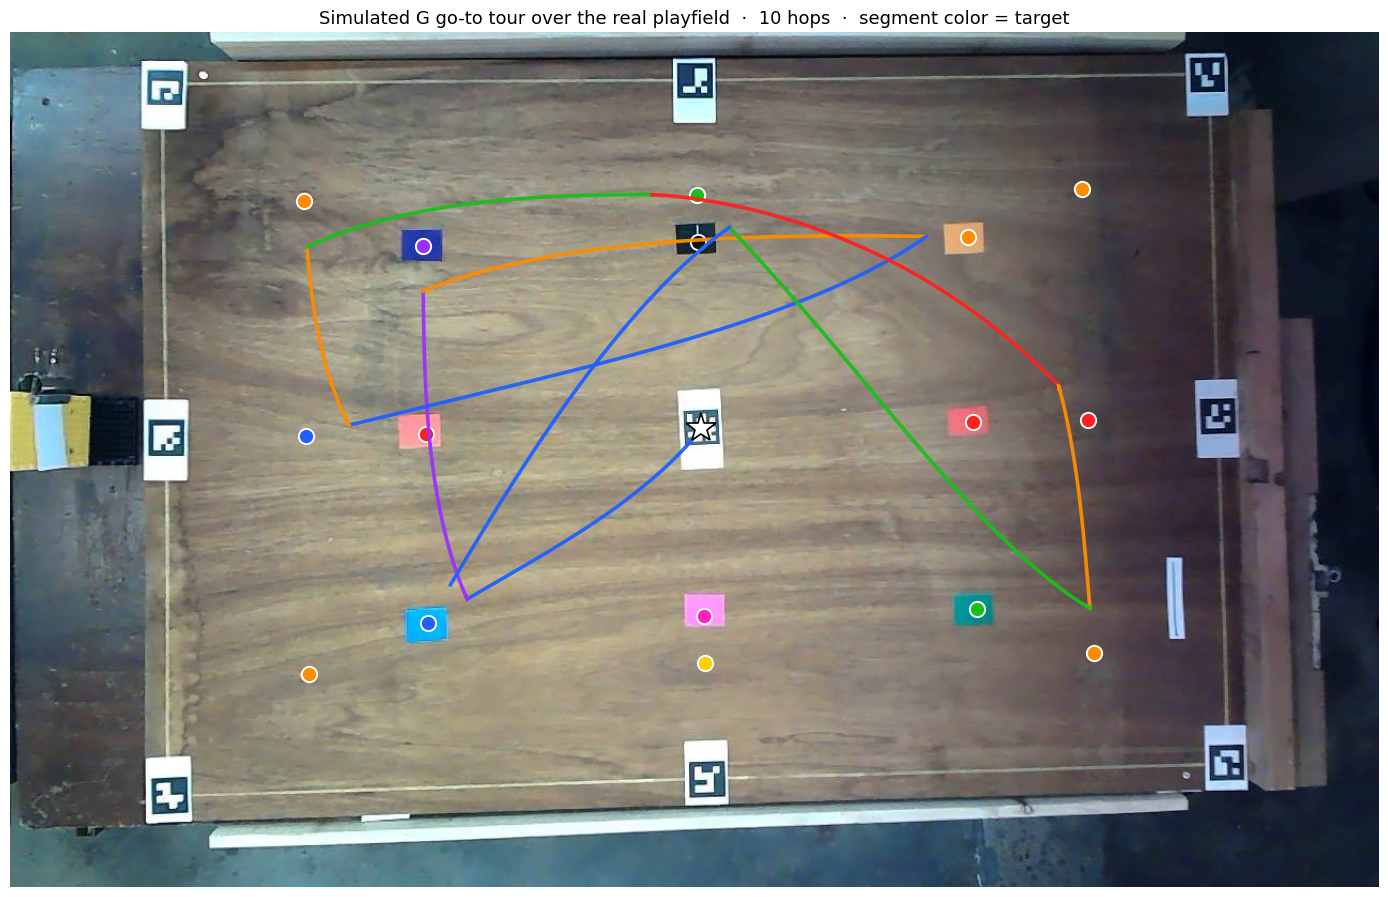

In [3]:
img = mpimg.imread(str(IMG))
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)

# target markers
for color, x, y in SITES:
    px, py = world_to_pixel(x, y)
    ax.plot(px, py, 'o', ms=11, mfc=CMAP.get(color, 'white'), mec='white', mew=1.4, zorder=3)

# path segments, colored by the target they head toward
for color, (sx, sy), pts, (tx, ty) in segments:
    if not pts:
        continue
    xs, ys = [], []
    for (wx, wy) in [(sx, sy)] + pts:
        px, py = world_to_pixel(wx, wy); xs.append(px); ys.append(py)
    ax.plot(xs, ys, '-', lw=2.6, color=CMAP.get(color, 'white'), alpha=0.95, zorder=4)

# start marker (robot began at A1 centre)
spx, spy = world_to_pixel(0, 0)
ax.plot(spx, spy, '*', ms=22, mfc='white', mec='black', mew=1.2, zorder=5)

ax.set_title(f"Simulated G go-to tour over the real playfield  ·  {len(segments)} hops  ·  "
             "segment color = target", fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.show()